In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")


# 1. Load & Prepare Data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/pheobebuffe/numero-esim-purchases/Copy of Numero eSIM_purchases (2024 - 2025).csv")

df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['register_date']  = pd.to_datetime(df['register_date'])
df = df.rename(columns={'prodcut': 'product'})
df['price'] = df['price'].fillna(df['price'].mean())

today = df['purchase_date'].max()

product_group_map = {
    'Phone Number':       'Virtual Number',
    'Local Calling Plan': 'Virtual Number',
    'EU Bundle':          'Virtual Number',
    'Full eSIM':          'Data eSIM',
    'Local eSIM':         'Data eSIM',
    'Data eSIM':          'Data eSIM',
    'Calling Offers':     'Calls',
    'Recharge':           'Calls',
}
df['product_group'] = df['product'].map(product_group_map)

print(df.shape)
df.head()

(826859, 14)


,id_client,purchase_date,product,product_type,details,renewal_status,price,User Country,User phone number,register_date,platform,email,language,product_group
0,15736044,2024-01-01,Data eSIM,Germany,1 GB,New,2.5,Germany,4915219617737,2024-01-01,iOS,NaN,english,Data eSIM
1,15736461,2024-01-01,Data eSIM,Spain,1 GB,New,3.0,Tunisia,21622062281,2024-01-01,iOS,NaN,french,Data eSIM
2,15736510,2024-01-01,Data eSIM,China,1 GB,New,5.0,Colombia,573155801176,2024-01-01,Android,NaN,spanish,Data eSIM
3,15736510,2024-01-01,Data eSIM,Indonesia,1 GB,New,5.0,Colombia,573155801176,2024-01-01,Android,NaN,spanish,Data eSIM
4,15737233,2024-01-01,Data eSIM,Australia,1 GB,New,4.0,Egypt,201018518052,2024-01-01,Android,NaN,arabic,Data eSIM


# 2. Client Feature Engineering (per Product Group)

In [3]:
def build_client_features(df_group, today):
    g = df_group.copy()

    base = g.groupby('id_client').agg(
        recency          = ('purchase_date', lambda x: (today - x.max()).days),
        customer_age     = ('register_date', lambda x: (today - x.min()).days),
        first_purchase   = ('purchase_date', 'min'),
        last_purchase    = ('purchase_date', 'max'),
        total_purchases  = ('price', 'count'),
        total_spent      = ('price', 'sum'),
        avg_order_value  = ('price', 'mean'),
        std_order_value  = ('price', 'std'),
        unique_products  = ('product',  'nunique'),
    ).reset_index()

    # Single-purchase clients have undefined std (ddof=1, n-1=0) → fill 0 (no spread)
    base['std_order_value'] = base['std_order_value'].fillna(0)

    active_days = (base['last_purchase'] - base['first_purchase']).dt.days
    base['purchase_velocity'] = (
        base['total_purchases'] / (active_days.clip(lower=1) / 30)
    )

    # Average gap between purchases
    gaps = (g.sort_values(['id_client', 'purchase_date'])
             .groupby('id_client')['purchase_date']
             .apply(lambda x: x.diff().dt.days.mean()))
    base = base.merge(gaps.rename('avg_gap_days').reset_index(), on='id_client', how='left')
    base['avg_gap_days'] = base['avg_gap_days'].fillna(active_days)

    # Per-product spend share within this group
    prod_spend = (g.groupby(['id_client', 'product'])['price']
                   .sum().unstack(fill_value=0).reset_index())
    prod_spend.columns = ['id_client'] + [
        f'spend_{c.lower().replace(" ", "_")}' for c in prod_spend.columns[1:]
    ]
    total = prod_spend.drop(columns='id_client').sum(axis=1).replace(0, np.nan)
    for c in prod_spend.columns[1:]:
        prod_spend[c.replace('spend_', 'share_')] = prod_spend[c] / total

    base = base.merge(prod_spend, on='id_client', how='left')
    base = base.drop(columns=['first_purchase', 'last_purchase'])
    return base


In [4]:
def cluster_clients(client_df, n_clusters, group_name):
    feature_cols = [c for c in client_df.columns if c != 'id_client']

    X = client_df[feature_cols].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=0.90, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    print(f"[{group_name}] PCA: {pca.n_components_} components → "
          f"{pca.explained_variance_ratio_.sum():.1%} variance explained")

    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=15)
    labels = km.fit_predict(X_pca)

    out = client_df.copy()
    out['cluster'] = labels
    out['PC1']     = X_pca[:, 0]
    out['PC2']     = X_pca[:, 1]
    return out, pca, scaler


In [5]:
def plot_cluster_profile(client_df, group_name):
    key_metrics = [
        'recency', 'customer_age', 'total_purchases', 'total_spent',
        'avg_order_value', 'unique_products', 'purchase_velocity', 'avg_gap_days',
    ]
    
    profile = client_df.groupby('cluster')[key_metrics].mean().round(2)

    # Normalised heatmap
    norm = MinMaxScaler().fit_transform(profile[key_metrics])
    norm_df = pd.DataFrame(norm, index=profile.index, columns=key_metrics)

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    fig.suptitle(f'Cluster Profiles — {group_name}', fontsize=13)

    # 1. Heatmap
    sns.heatmap(norm_df, annot=profile.values, fmt='.1f',
                cmap='YlOrRd', linewidths=0.5, ax=axes[0],
                cbar_kws={'label': 'Normalised'})
    axes[0].set_title('Profile Heatmap (raw values shown)')
    axes[0].set_xlabel('Feature'); axes[0].set_ylabel('Cluster')

    # 2. PCA scatter
    sns.scatterplot(data=client_df, x='PC1', y='PC2',
                    hue='cluster', palette='tab10', s=25, alpha=0.7, ax=axes[1])
    axes[1].set_title('PCA Scatter (PC1 vs PC2)')
    axes[1].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

    # 3. Total spend box
    sns.boxplot(data=client_df, x='cluster', y='total_spent',
                palette='tab10', showfliers=False, ax=axes[2])
    axes[2].set_title('Total Spent by Cluster')

    plt.tight_layout()
    plt.show()

    print(profile.to_string())
    print()


---
# 3. Calls — Client Clustering

In [6]:
df_calls = df[df['product_group'] == 'Calls'].copy()
calls_clients = build_client_features(df_calls, today)
print(f"Calls: {calls_clients.shape[0]:,} unique clients, {calls_clients.shape[1]} features")

Calls: 57,197 unique clients, 14 features


In [7]:
CALLS_K = 4   

calls_clustered, calls_pca, calls_scaler = cluster_clients(calls_clients, CALLS_K, 'Calls')
print(calls_clustered['cluster'].value_counts().sort_index())

[Calls] PCA: 8 components → 91.6% variance explained
cluster
0     7291
1    38416
2    11410
3       80
Name: count, dtype: int64


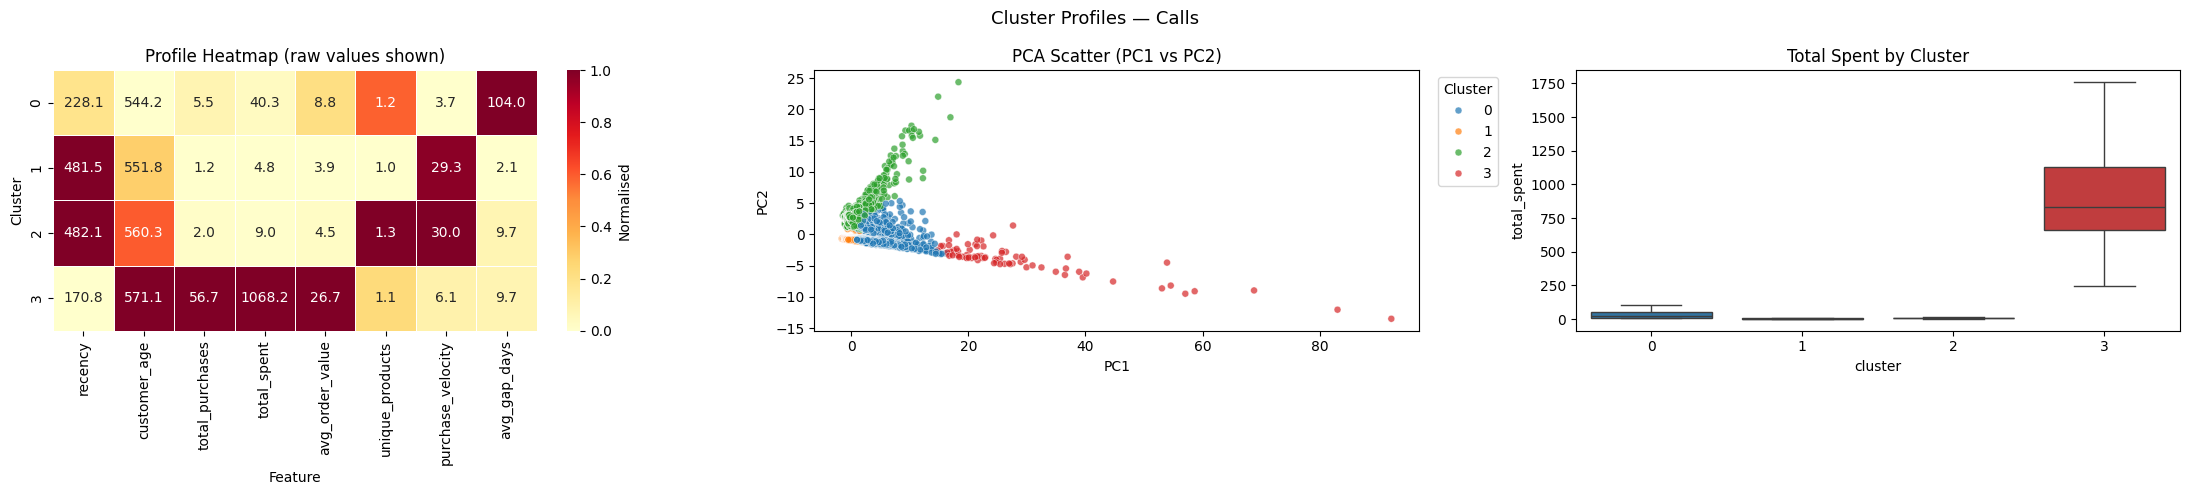

         recency  customer_age  total_purchases  total_spent  avg_order_value  unique_products  purchase_velocity  avg_gap_days
cluster                                                                                                                        
0         228.05        544.16             5.47        40.29             8.82             1.20               3.72        104.05
1         481.51        551.80             1.24         4.83             3.92             1.00              29.34          2.12
2         482.13        560.29             1.99         9.01             4.45             1.34              30.00          9.66
3         170.81        571.10            56.70      1068.25            26.73             1.08               6.14          9.69



In [8]:
plot_cluster_profile(calls_clustered, 'Calls')

In [9]:
calls_clustered.groupby('cluster').mean(numeric_only=True)

,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_calling_offers,spend_recharge,share_calling_offers,share_recharge,PC1,PC2
cluster,,,,,,,,,,,,,,,,
0,1.841108e+07,228.050062,544.157866,5.468249,40.285570,8.815068,4.538054,1.204362,3.723032,104.051781,1.563186,38.722384,0.070308,0.929692,2.430245,-0.403600
1,1.831067e+07,481.509345,551.796699,1.237323,4.834137,3.921922,0.249416,1.000937,29.343916,2.117313,0.001874,4.832263,0.000136,0.999864,-0.512024,-0.780353
2,1.819863e+07,482.131989,560.287905,1.988344,9.010191,4.452180,0.639088,1.342068,30.003081,9.657124,7.258824,1.751367,0.861998,0.138002,-0.025231,2.913687
3,1.802249e+07,170.812500,571.100000,56.700000,1068.250000,26.731569,12.512764,1.075000,6.137155,9.692189,1.225000,1067.025000,0.001576,0.998424,27.986320,-4.056226


| Cluster | Segment Name        | Value     | Activity  | Strategy         |
| ------- | ------------------- | --------- | --------- | ---------------- |
| 0       | At-Risk Customers   | Medium    | Low       | Reactivate       |
| 1       | One-Time Customers  | Very Low  | Very Low  | Low priority     |
| 2       | Active Offer-Driven Customers | Medium    | High      | Promote & upsell |
| 3       | High-Value Power Users   | Very High | Very High | Retain & reward  |


In [10]:
calls_cluster_names = {
    0: 'Calls - At-Risk Customers',
    1: 'Calls - One-Time Customers',
    2: 'Calls - Active Offer-Driven Customers',
    3: 'Calls - High-Value Power Users'
}

calls_clustered['cluster_name'] = calls_clustered['cluster'].map(calls_cluster_names)
calls_clustered.head()


,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_calling_offers,spend_recharge,share_calling_offers,share_recharge,cluster,PC1,PC2,cluster_name
0,15735920,730,730,1,2.0,2.0,0.0,1,30.000000,0.0,0.0,2.0,0.0,1.0,1,-1.169397,-0.642152,Calls - One-Time Customers
1,15735936,730,730,1,2.0,2.0,0.0,1,30.000000,0.0,0.0,2.0,0.0,1.0,1,-1.169397,-0.642152,Calls - One-Time Customers
2,15735986,730,730,1,2.0,2.0,0.0,1,30.000000,0.0,0.0,2.0,0.0,1.0,1,-1.169397,-0.642152,Calls - One-Time Customers
3,15736016,720,730,2,4.0,2.0,0.0,1,8.571429,7.0,0.0,4.0,0.0,1.0,1,-0.685326,-0.658307,Calls - One-Time Customers
4,15736376,671,730,6,12.0,2.0,0.0,1,3.050847,11.8,0.0,12.0,0.0,1.0,1,0.063638,-0.673053,Calls - One-Time Customers


In [11]:
calls_clustered.to_csv('Client_Calls_Clustered.csv', index=False)
print("Saved: Client_Calls_Clustered.csv")

Saved: Client_Calls_Clustered.csv


---
# 4. Data eSIM — Client Clustering

In [12]:
df_esim = df[df['product_group'] == 'Data eSIM'].copy()
esim_clients = build_client_features(df_esim, today)
print(f"eSIM: {esim_clients.shape[0]:,} unique clients, {esim_clients.shape[1]} features")

eSIM: 73,125 unique clients, 16 features


In [13]:
ESIM_K = 3   

esim_clustered, esim_pca, esim_scaler = cluster_clients(esim_clients, ESIM_K, 'Data eSIM')
print(esim_clustered['cluster'].value_counts().sort_index())

[Data eSIM] PCA: 8 components → 90.5% variance explained
cluster
0     6504
1    14703
2    51918
Name: count, dtype: int64


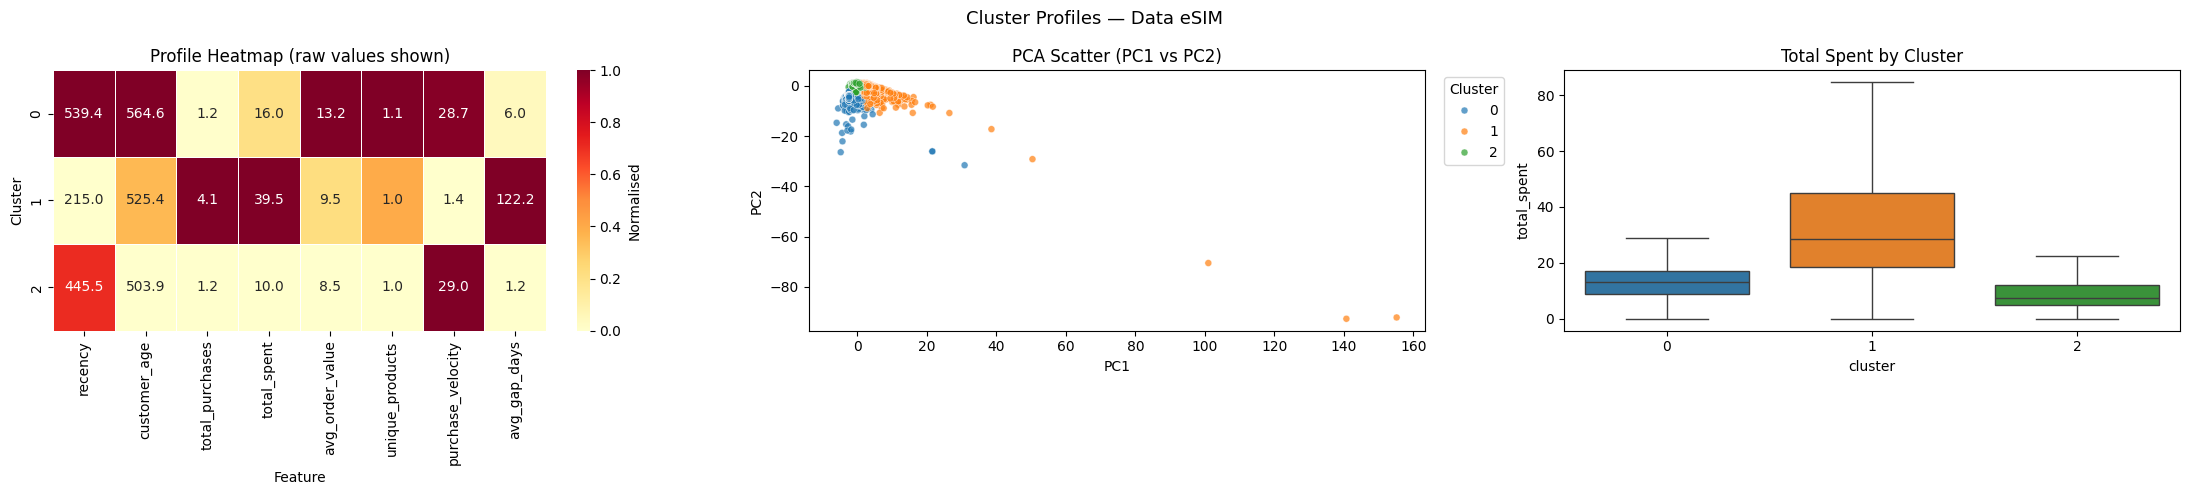

         recency  customer_age  total_purchases  total_spent  avg_order_value  unique_products  purchase_velocity  avg_gap_days
cluster                                                                                                                        
0         539.35        564.57             1.22        15.99            13.22             1.10              28.70          6.00
1         215.04        525.39             4.13        39.48             9.51             1.04               1.37        122.20
2         445.46        503.91             1.20        10.00             8.46             1.00              29.03          1.18



In [14]:
plot_cluster_profile(esim_clustered, 'Data eSIM')

In [15]:
esim_clustered.groupby('cluster').mean(numeric_only=True)

,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_data_esim,spend_full_esim,spend_local_esim,share_data_esim,share_full_esim,share_local_esim,PC1,PC2
cluster,,,,,,,,,,,,,,,,,,
0,1.814654e+07,539.352706,564.573647,1.222786,15.991907,13.217979,0.665784,1.103782,28.699659,6.003900,1.631316,0.014723,14.345867,0.038053,0.000402,0.961545,-2.463765,-4.585528
1,1.867047e+07,215.037883,525.387812,4.128273,39.480337,9.512212,3.955757,1.042576,1.367517,122.195004,39.031968,0.253195,0.195174,0.984868,0.010432,0.004700,2.620375,-0.132156
2,1.895850e+07,445.460457,503.907181,1.198852,9.995651,8.459972,0.323854,1.000347,29.031028,1.178153,9.944928,0.050723,0.000000,0.991767,0.008233,0.000000,-0.433434,0.611876


| Cluster | Segment Name       | Value  | Behavior               | Strategy           |
| ------- | ------------------ | ------ | ---------------------- | ------------------ |
| 0       | Local Data Users (Occasional Travelers)    | Medium | Occasional, local-only | Increase frequency |
| 1       | Global Power Users | High   | Loyal, high spend      | Retain & upsell    |
| 2       | Data-Only Minimal Users   | Low    | One-time, minimal      | Convert            |


In [16]:
esim_cluster_names = {
    0: 'eSIM - Local Data Users',
    1: 'eSIM - High-Value Global Power Users',
    2: 'eSIM - Data-Only Minimal Users'
}

esim_clustered['cluster_name'] = esim_clustered['cluster'].map(esim_cluster_names)
esim_clustered.head()


,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_data_esim,spend_full_esim,spend_local_esim,share_data_esim,share_full_esim,share_local_esim,cluster,PC1,PC2,cluster_name
0,15735905,730,730,1,9.0,9.00,0.00000,1,30.000000,0.0,0.0,0.0,9.0,0.0,0.0,1.0,0,-3.110707,-4.120931,eSIM - Local Data Users
1,15736044,574,730,2,5.0,2.50,0.00000,1,0.384615,156.0,5.0,0.0,0.0,1.0,0.0,0.0,1,0.489899,0.395717,eSIM - High-Value Global Power Users
2,15736049,7,730,2,28.0,14.00,0.00000,1,1.621622,37.0,28.0,0.0,0.0,1.0,0.0,0.0,1,1.695883,0.056640,eSIM - High-Value Global Power Users
3,15736262,394,730,1,3.5,3.50,0.00000,1,30.000000,0.0,3.5,0.0,0.0,1.0,0.0,0.0,2,-0.710803,0.584269,eSIM - Data-Only Minimal Users
4,15736435,9,730,2,21.5,10.75,1.06066,1,0.083333,720.0,21.5,0.0,0.0,1.0,0.0,0.0,1,4.286040,0.063841,eSIM - High-Value Global Power Users


In [17]:
esim_clustered.to_csv('Client_eSIM_Clustered.csv', index=False)
print("Saved: Client_eSIM_Clustered.csv")

Saved: Client_eSIM_Clustered.csv


---
# 5. Virtual Number — Client Clustering

In [18]:
df_virtual = df[df['product_group'] == 'Virtual Number'].copy()
virtual_clients = build_client_features(df_virtual, today)
print(f"Virtual: {virtual_clients.shape[0]:,} unique clients, {virtual_clients.shape[1]} features")

Virtual: 204,821 unique clients, 16 features


In [19]:
VIRTUAL_K = 5   

virtual_clustered, virtual_pca, virtual_scaler = cluster_clients(virtual_clients, VIRTUAL_K, 'Virtual Number')
print(virtual_clustered['cluster'].value_counts().sort_index())

[Virtual Number] PCA: 9 components → 92.0% variance explained
cluster
0    144363
1     44646
2     12278
3      3415
4       119
Name: count, dtype: int64


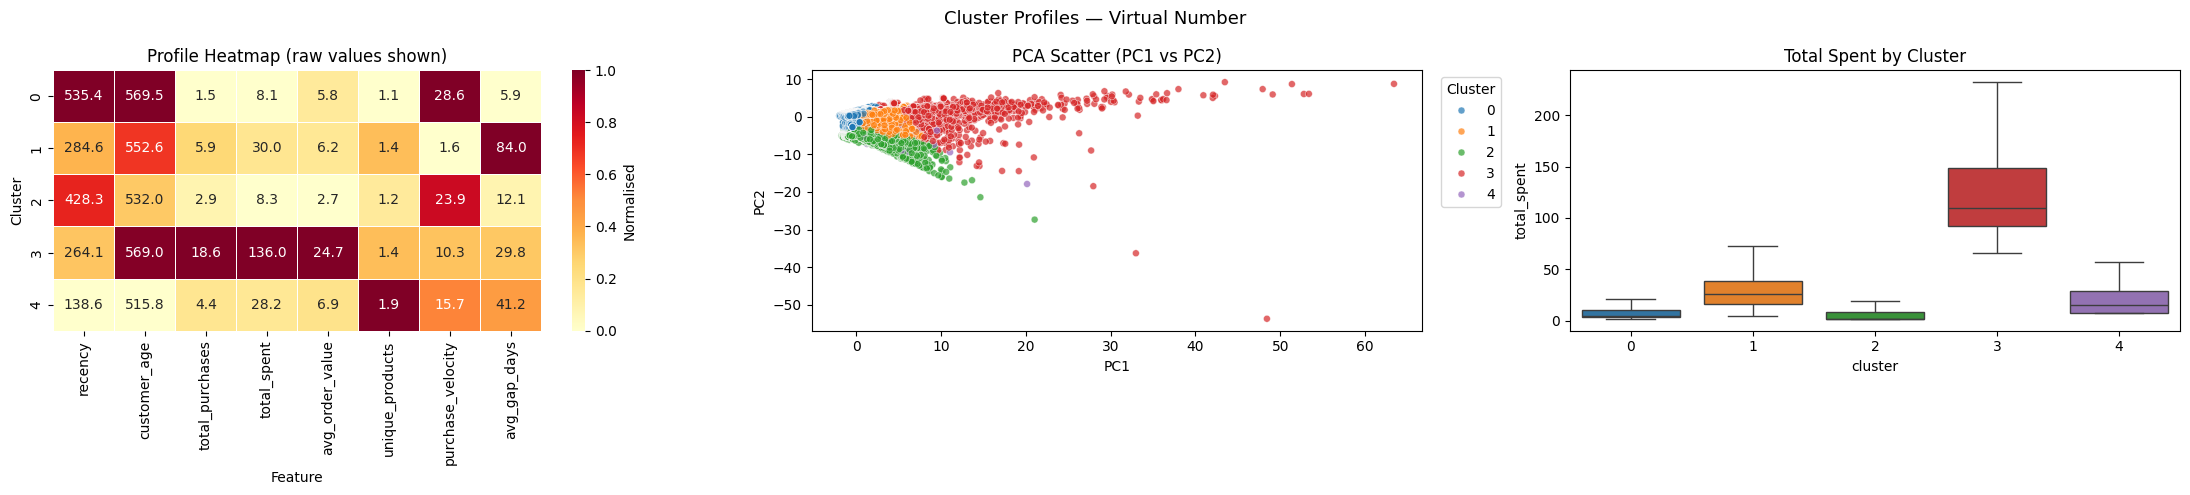

         recency  customer_age  total_purchases  total_spent  avg_order_value  unique_products  purchase_velocity  avg_gap_days
cluster                                                                                                                        
0         535.40        569.47             1.53         8.09             5.80             1.10              28.62          5.92
1         284.62        552.61             5.86        30.00             6.18             1.36               1.63         84.00
2         428.27        531.96             2.89         8.35             2.68             1.21              23.92         12.13
3         264.05        568.97            18.61       136.02            24.70             1.36              10.32         29.80
4         138.64        515.82             4.40        28.25             6.88             1.87              15.65         41.24



In [20]:
plot_cluster_profile(virtual_clustered, 'Virtual Number')

In [21]:
virtual_clustered.groupby('cluster').mean(numeric_only=True)

,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_eu_bundle,spend_local_calling_plan,spend_phone_number,share_eu_bundle,share_local_calling_plan,share_phone_number,PC1,PC2
cluster,,,,,,,,,,,,,,,,,,
0,1.807124e+07,535.397269,569.465057,1.525363,8.088696,5.802467,0.456192,1.100330,28.615063,5.917269,0.000000,0.227579,7.861117,0.000000,0.026965,0.973035,-0.785810,0.350335
1,1.830302e+07,284.620974,552.608476,5.857591,30.004554,6.182301,2.238415,1.360749,1.634742,83.996945,0.007705,1.480110,28.516739,0.000182,0.059940,0.939877,1.925531,0.143520
2,1.858516e+07,428.270728,531.963186,2.894853,8.350894,2.677337,0.319091,1.208259,23.923217,12.133008,0.001955,6.635608,1.713331,0.000039,0.912900,0.087061,-0.133085,-4.994810
3,1.809028e+07,264.054173,568.970425,18.609078,136.018826,24.695857,11.015259,1.363982,10.323454,29.804004,0.011713,3.585066,132.422047,0.000098,0.025631,0.974271,8.423078,1.459196
4,1.879396e+07,138.638655,515.823529,4.403361,28.253529,6.883738,1.865888,1.865546,15.652470,41.237459,14.789916,2.747899,10.715714,0.708545,0.078011,0.213444,2.889702,-5.376793


| Cluster | Segment Name                | Value       | Behavior                                 | Strategy                  |
| ------- | --------------------------- | ----------- | ---------------------------------------- | ------------------------- |
| 0       | Churned Low-Value Users     | Low         | Inactive, one-time, phone-number focused | Reactivate or ignore      |
| 1       | Loyal Infrequent Buyers     | Medium      | Long-term, very infrequent purchases     | Increase frequency        |
| 2       | Low-Value Local Plan Users  | Low         | Short-term, local-plan focused           | Convert / upsell          |
| 3       | High-Value Power Users      | Very High   | Frequent, high spend, highly active      | Retain & maximize value   |
| 4       | EU Bundle Focused Customers | Medium-High | Product-focused, moderate engagement     | Cross-sell & expand usage |


In [22]:
virtual_cluster_names = {
    0: 'Virtual - Churned Low-Value Users',
    1: 'Virtual - Loyal Infrequent Buyers',
    2: 'Virtual - Low-Value Single-Product Users (Local Plan)',
    3: 'Virtual - High-Value Power Users',
    4: 'Virtual - EU Bundle Focused Customers'
}

virtual_clustered['cluster_name'] = virtual_clustered['cluster'].map(virtual_cluster_names)
virtual_clustered.head()


,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_eu_bundle,spend_local_calling_plan,spend_phone_number,share_eu_bundle,share_local_calling_plan,share_phone_number,cluster,PC1,PC2,cluster_name
0,15735847,730,730,1,6.00,6.00,0.000000,1,30.000000,0.0,0.0,0.0,6.00,0.0,0.000000,1.000000,0,-1.462932,0.749592,Virtual - Churned Low-Value Users
1,15735879,730,730,1,3.49,3.49,0.000000,1,30.000000,0.0,0.0,0.0,3.49,0.0,0.000000,1.000000,0,-1.625322,0.647462,Virtual - Churned Low-Value Users
2,15735902,730,730,1,17.99,17.99,0.000000,1,30.000000,0.0,0.0,0.0,17.99,0.0,0.000000,1.000000,0,-0.687211,1.237456,Virtual - Churned Low-Value Users
3,15735905,730,730,2,6.00,3.00,1.414214,2,60.000000,0.0,0.0,2.0,4.00,0.0,0.333333,0.666667,0,-1.214478,-2.190736,Virtual - Churned Low-Value Users
4,15735933,414,730,2,6.98,3.49,0.000000,1,1.935484,31.0,0.0,0.0,6.98,0.0,0.000000,1.000000,0,-0.330745,0.740736,Virtual - Churned Low-Value Users


In [23]:
virtual_clustered.to_csv('Client_Virtual_Clustered.csv', index=False)
print("Saved: Client_Virtual_Clustered.csv")

Saved: Client_Virtual_Clustered.csv


---
# 6. All Datasets — Client Clustering

In [32]:
def prepare_df(df, prefix):
    df[f'has_{prefix}'] = 1
    
    segments = pd.get_dummies(df['cluster_name'], prefix='segment')
    df = pd.concat([df, segments], axis=1)
    
    cols_to_rename = {
        'total_spent': f'spend_{prefix}',
        'total_purchases': f'purchases_{prefix}',
        'recency': f'recency_{prefix}',
        'cluster_name': f'segment_{prefix}'
    }
    return df.rename(columns=cols_to_rename)

calls_prep = prepare_df(calls_clustered, 'calls')
esim_prep = prepare_df(esim_clustered, 'esim')
virtual_prep = prepare_df(virtual_clustered, 'virtual')

In [33]:
df_final = calls_prep.merge(esim_prep, on='id_client', how='outer') \
                     .merge(virtual_prep, on='id_client', how='outer')


In [34]:
# 1. Product Groups (String)
def get_prod_string(row):
    prods = []
    if row.get('has_calls') == 1: prods.append('Calls')
    if row.get('has_esim') == 1: prods.append('Data eSIM')
    if row.get('has_virtual') == 1: prods.append('Virtual Number')
    return ", ".join(prods)

df_final['product_group'] = df_final.apply(get_prod_string, axis=1)

# 2. Global Recency (The most recent activity)
df_final['recency'] = df_final[['recency_calls', 'recency_esim', 'recency_virtual']].min(axis=1)

# 3. Total Purchase Count
df_final['total_purchase_count'] = df_final[['purchases_calls', 'purchases_esim', 'purchases_virtual']].sum(axis=1)

# 4. Total Spend
df_final['total_spend'] = df_final[['spend_calls', 'spend_esim', 'spend_virtual']].sum(axis=1)


In [38]:
all_segment_binary_cols = [c for c in df_final.columns if c.startswith('segment_') and not c.endswith(('_calls', '_esim', '_virtual'))]

final_cols = [
    'id_client', 
    'has_calls', 'has_esim', 'has_virtual', 
    'product_group',                     
    'recency', 'total_purchase_count', 'total_spend'   
] + all_segment_binary_cols               

df_final = df_final[final_cols]

In [39]:
binary_cols = [c for c in df_final.columns if c.startswith('has_') or c.startswith('segment_')]

df_final[binary_cols] = df_final[binary_cols].fillna(0).astype(int)

In [40]:
df_final = pd.merge(
    df_final, 
    df[['id_client', 'User Country', 'platform', 'language', 'User phone number']]
        .drop_duplicates(subset=['id_client']), 
    on='id_client', 
    how='left'
)

In [41]:
df_final

,id_client,has_calls,has_esim,has_virtual,product_group,recency,total_purchase_count,total_spend,segment_Calls - Active Offer-Driven Customers,segment_Calls - At-Risk Customers,...,segment_eSIM - Local Data Users,segment_Virtual - Churned Low-Value Users,segment_Virtual - EU Bundle Focused Customers,segment_Virtual - High-Value Power Users,segment_Virtual - Low-Value Single-Product Users (Local Plan),segment_Virtual - Loyal Infrequent Buyers,User Country,platform,language,User phone number
0,15735847,0,0,1,Virtual Number,730.0,1.0,6.00,0,0,...,0,1,0,0,0,0,Pakistan,iOS,english,923126335257
1,15735879,0,0,1,Virtual Number,730.0,1.0,3.49,0,0,...,0,1,0,0,0,0,Indonesia,Android,english,6281337725179
2,15735902,0,0,1,Virtual Number,730.0,1.0,17.99,0,0,...,0,1,0,0,0,0,UK,Android,english,447450985551
3,15735905,0,1,1,"Data eSIM, Virtual Number",730.0,3.0,15.00,0,0,...,1,1,0,0,0,0,KSA,Android,arabic,966572696109
4,15735920,1,0,0,Calls,730.0,1.0,2.00,0,0,...,0,0,0,0,0,0,Senegal,Android,french,221761210221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278169,20563132,0,0,1,Virtual Number,352.0,2.0,6.98,0,0,...,0,1,0,0,0,0,Switzerland,Android,french,41774746974
278170,20563135,0,0,1,Virtual Number,361.0,1.0,3.49,0,0,...,0,1,0,0,0,0,Bolivia,Android,spanish,59176155268
278171,20563151,0,0,1,Virtual Number,66.0,1.0,3.49,0,0,...,0,1,0,0,0,0,Nigeria,Android,english,2348101277751
278172,20563159,1,0,0,Calls,49.0,7.0,26.00,1,0,...,0,0,0,0,0,0,Pakistan,iOS,english,923364680223


In [31]:
df_final.isna().sum()

id_client                                                          0
has_calls                                                          0
has_esim                                                           0
has_virtual                                                        0
product_types                                                      0
recency                                                            0
total_purchase_count                                               0
total_spend                                                        0
segment_Calls - Active Offer-Driven Customers                      0
segment_Calls - At-Risk Customers                                  0
segment_Calls - High-Value Power Users                             0
segment_Calls - One-Time Customers                                 0
segment_eSIM - Data-Only Minimal Users                             0
segment_eSIM - High-Value Global Power Users                       0
segment_eSIM - Local Data Users   